In [4]:
import pandas as pd
from pulp import *

In [2]:
!pip install pulp

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   -------- ------------------------------- 3.7/16.4 MB 36.2 MB/s eta 0:00:01
   -------------------------- ------------- 11.0/16.4 MB 35.0 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 32.9 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
from pulp import *

In [5]:
manvar_costs = pd.read_excel('variable_costs.xlsx', index_col=0)
freight_costs = pd.read_excel('freight_costs.xlsx', index_col=0)
fixed_costs   = pd.read_excel('fixed_cost.xlsx',    index_col=0)
cap           = pd.read_excel('capacity.xlsx',       index_col=0)
demand        = pd.read_excel('demand.xlsx',          index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: 'variable_costs.xlsx'

In [2]:
import os

In [5]:
folder = r'C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization'

manvar_costs  = pd.read_excel(os.path.join(folder, 'variable_costs.xlsx'), index_col=0)
freight_costs = pd.read_excel(os.path.join(folder, 'freight_costs.xlsx'),  index_col=0)
fixed_costs   = pd.read_excel(os.path.join(folder, 'fixed_cost.xlsx'),     index_col=0)
cap           = pd.read_excel(os.path.join(folder, 'capacity.xlsx'),        index_col=0)
demand        = pd.read_excel(os.path.join(folder, 'demand.xlsx'),          index_col=0)

print("All files loaded successfully!")

All files loaded successfully!


In [6]:
var_cost = freight_costs / 1000 + manvar_costs

In [7]:
loc  = ['USA', 'Germany', 'Japan', 'Brazil', 'India']
size = ['Low', 'High']

model = LpProblem("Supply Chain Optimization", LpMinimize)

x = LpVariable.dicts("production_",
        [(i,j) for i in loc for j in loc],
        lowBound=0, cat='Continuous')

y = LpVariable.dicts("plant_",
        [(i,s) for s in size for i in loc],
        cat='Binary')

C:\Users\rvagh\AppData\Local\Programs\Python\Python314\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


In [17]:
# SCENARIO 1
model_s1 = LpProblem("Scenario1_Baseline", LpMinimize)

x1 = LpVariable.dicts("prod1_", [(i,j) for i in loc for j in loc],
                       lowBound=0, cat='Continuous')
y1 = LpVariable.dicts("plant1_", [(i,s) for s in size for i in loc],
                       cat='Binary')

model_s1 += (
    lpSum([fixed_costs.loc[i,s] * y1[(i,s)] * 1000
           for s in size for i in loc])
  + lpSum([var_cost.loc[i,j] * x1[(i,j)]
           for i in loc for j in loc])
)

for j in loc:
    model_s1 += lpSum([x1[(i,j)] for i in loc]) == demand.loc[j,'Demand']

for i in loc:
    model_s1 += lpSum([x1[(i,j)] for j in loc]) <= lpSum([cap.loc[i,s] * y1[(i,s)] * 1000
                                                            for s in size])
model_s1.solve()
cost_s1 = int(value(model_s1.objective))
print("SCENARIO 1 — Baseline")
print("Total Cost = {:,} ($/Month)".format(cost_s1))
print("Status:", LpStatus[model_s1.status])

SCENARIO 1 — Baseline
Total Cost = 92,981,000 ($/Month)
Status: Optimal


In [8]:
model += (
    lpSum([fixed_costs.loc[i,s] * y[(i,s)] * 1000
           for s in size for i in loc])
  + lpSum([var_cost.loc[i,j] * x[(i,j)]
           for i in loc for j in loc])
)

In [9]:
for j in loc:
    model += lpSum([x[(i,j)] for i in loc]) == demand.loc[j, 'Demand']

for i in loc:
    model += lpSum([x[(i,j)] for j in loc]) <= lpSum([cap.loc[i,s] * y[(i,s)] * 1000
                                                       for s in size])

In [10]:
model.solve()
print("Total Costs = {:,} ($/Month)".format(int(value(model.objective))))
print("Status: {}".format(LpStatus[model.status]))

dict_plant = {}
dict_prod  = {}

for v in model.variables():
    if 'plant' in v.name:
        name = v.name.replace('plant__','').replace('_','')
        dict_plant[name] = int(v.varValue)
    else:
        name = v.name.replace('production__','').replace('_','')
        dict_prod[name] = v.varValue
    print(name, "=", v.varValue)

Total Costs = 92,981,000 ($/Month)
Status: Optimal
('Brazil','High') = 0.0
('Brazil','Low') = 1.0
('Germany','High') = 0.0
('Germany','Low') = 0.0
('India','High') = 1.0
('India','Low') = 0.0
('Japan','High') = 1.0
('Japan','Low') = 0.0
('USA','High') = 1.0
('USA','Low') = 0.0
('Brazil','Brazil') = 145000.0
('Brazil','Germany') = 0.0
('Brazil','India') = 0.0
('Brazil','Japan') = 0.0
('Brazil','USA') = 0.0
('Germany','Brazil') = 0.0
('Germany','Germany') = 0.0
('Germany','India') = 0.0
('Germany','Japan') = 0.0
('Germany','USA') = 0.0
('India','Brazil') = 0.0
('India','Germany') = 90000.0
('India','India') = 160000.0
('India','Japan') = 0.0
('India','USA') = 1500000.0
('Japan','Brazil') = 0.0
('Japan','Germany') = 0.0
('Japan','India') = 0.0
('Japan','Japan') = 1500000.0
('Japan','USA') = 0.0
('USA','Brazil') = 0.0
('USA','Germany') = 0.0
('USA','India') = 0.0
('USA','Japan') = 200000.0
('USA','USA') = 1300000.0


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.sankey import Sankey
import matplotlib.colors as mcolors
import numpy as np
 
print("Visualization libraries loaded")
 

Visualization libraries loaded


In [26]:
import os

results_folder = r"C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization"

# Create folder if it doesn't exist
os.makedirs(results_folder, exist_ok=True)

print(f"Images will be saved to: {results_folder}")

Images will be saved to: C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization


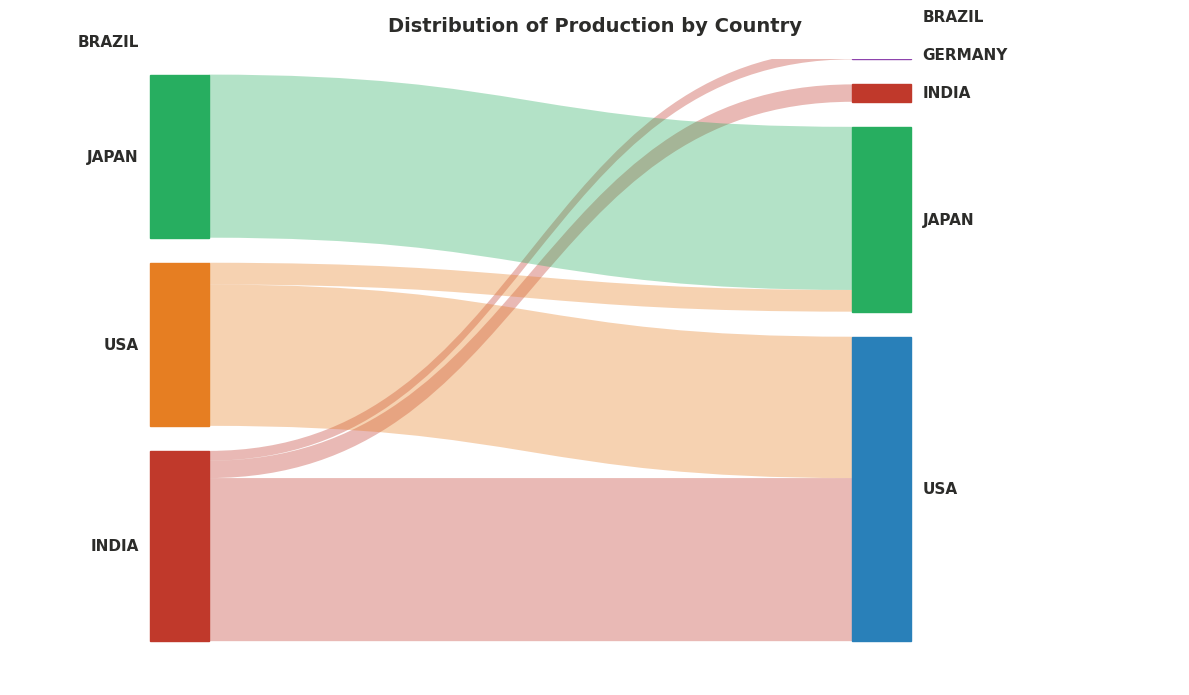

Saved: chart1_sankey.png


In [27]:
fig, ax = plt.subplots(figsize=(12, 7))  #  Sankey chart
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
 
# --- data from your model results ---
sources = ['INDIA', 'USA', 'JAPAN', 'BRAZIL']
targets = ['USA', 'JAPAN', 'INDIA', 'GERMANY', 'BRAZIL']
src_colors = ['#C0392B', '#E67E22', '#27AE60', '#2980B9']
tgt_colors = ['#2980B9', '#27AE60', '#C0392B', '#8E44AD', '#E67E22']
 
flows = {
    ('INDIA',  'USA'):     1500,
    ('INDIA',  'INDIA'):   160,
    ('INDIA',  'GERMANY'): 90,
    ('USA',    'USA'):     1300,
    ('USA',    'JAPAN'):   200,
    ('JAPAN',  'JAPAN'):   1500,
    ('BRAZIL', 'BRAZIL'):  145,
}
 
src_totals = {s: sum(v for (src,_),v in flows.items() if src==s) for s in sources}
tgt_totals = {t: sum(v for (_,tgt),v in flows.items() if tgt==t) for t in targets}
total = sum(flows.values())
 
# draw source bars
lx, rx = 0.12, 0.72
bar_w = 0.05
y_gap = 0.04
avail = 0.85
 
src_bars, sy = {}, 0.07
for i, s in enumerate(sources):
    h = (src_totals[s] / total) * avail
    src_bars[s] = {'y': sy, 'h': h, 'color': src_colors[i]}
    ax.add_patch(plt.Rectangle((lx, sy), bar_w, h,
                 color=src_colors[i], transform=ax.transAxes, zorder=3))
    ax.text(lx - 0.01, sy + h/2, s, ha='right', va='center',
            fontsize=11, fontweight='bold', transform=ax.transAxes, color='#2C2C2A')
    sy += h + y_gap
 
tgt_bars, ty = {}, 0.07
for i, t in enumerate(targets):
    h = (tgt_totals[t] / total) * avail
    tgt_bars[t] = {'y': ty, 'h': h, 'color': tgt_colors[i]}
    ax.add_patch(plt.Rectangle((rx, ty), bar_w, h,
                 color=tgt_colors[i], transform=ax.transAxes, zorder=3))
    ax.text(rx + bar_w + 0.01, ty + h/2, t, ha='left', va='center',
            fontsize=11, fontweight='bold', transform=ax.transAxes, color='#2C2C2A')
    ty += h + y_gap
 
# draw flows
src_offsets = {s: 0 for s in sources}
tgt_offsets = {t: 0 for t in targets}
 
from matplotlib.patches import PathPatch
from matplotlib.path import Path
 
for (src, tgt), val in flows.items():
    sb = src_bars[src]; tb = tgt_bars[tgt]
    sh = (val / src_totals[src]) * sb['h']
    th = (val / tgt_totals[tgt]) * tb['h']
    sy0 = sb['y'] + src_offsets[src]
    ty0 = tb['y'] + tgt_offsets[tgt]
    x0 = lx + bar_w; x1 = rx
    mx = (x0 + x1) / 2
    verts = [(x0, sy0),(mx, sy0),(mx, ty0),(x1, ty0),
             (x1, ty0+th),(mx, ty0+th),(mx, sy0+sh),(x0, sy0+sh),(x0, sy0)]
    codes = [Path.MOVETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,
             Path.LINETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,Path.CLOSEPOLY]
    patch = PathPatch(Path(verts, codes),
                      facecolor=sb['color'], alpha=0.35, edgecolor='none',
                      transform=ax.transAxes, zorder=2)
    ax.add_patch(patch)
    src_offsets[src] += sh
    tgt_offsets[tgt] += th
 
ax.set_title('Distribution of Production by Country', fontsize=14,
             fontweight='bold', pad=20, color='#2C2C2A')
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'chart1_sankey.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart1_sankey.png")

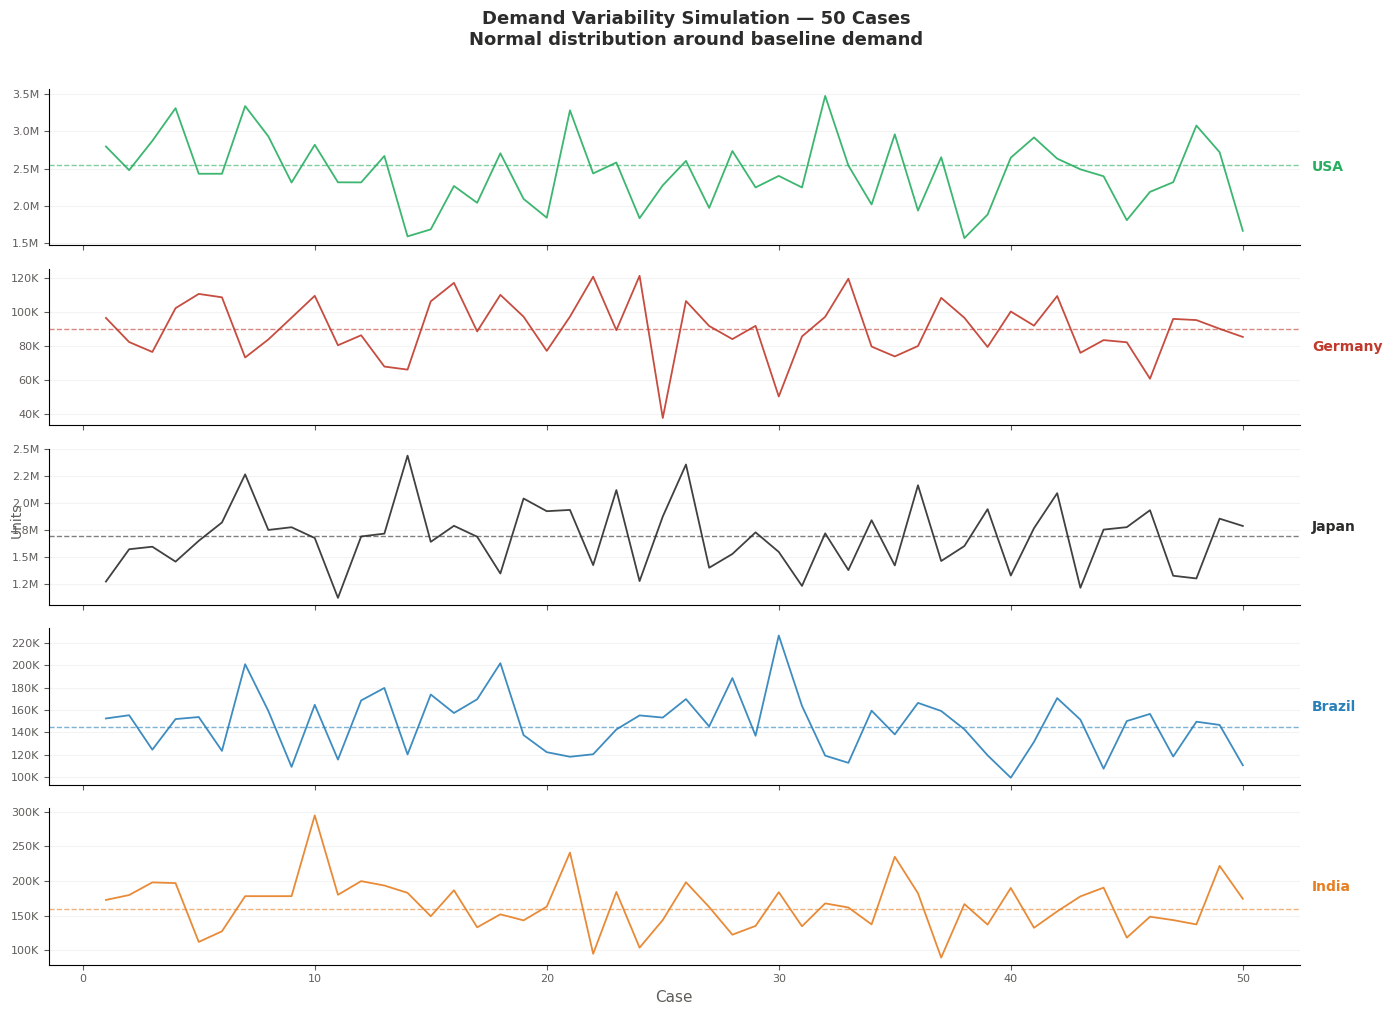

Saved: chart2_demand_variability.png


In [28]:
np.random.seed(42)   # Demand variability
N = 50
cases_x = np.arange(1, N+1)
 
markets = [
    {'name': 'USA',     'base': 2550000, 'std': 500000, 'color': '#27AE60'},
    {'name': 'Germany', 'base': 90000,   'std': 20000,  'color': '#C0392B'},
    {'name': 'Japan',   'base': 1700000, 'std': 300000, 'color': '#2C2C2A'},
    {'name': 'Brazil',  'base': 145000,  'std': 30000,  'color': '#2980B9'},
    {'name': 'India',   'base': 160000,  'std': 35000,  'color': '#E67E22'},
]
 
fig, axes = plt.subplots(len(markets), 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor('white')
 
for i, (m, ax2) in enumerate(zip(markets, axes)):
    demand = np.random.normal(m['base'], m['std'], N).clip(min=0)
    ax2.plot(cases_x, demand, color=m['color'], linewidth=1.3, alpha=0.9)
    ax2.axhline(m['base'], color=m['color'], linewidth=1,
                linestyle='--', alpha=0.6)
    ax2.set_facecolor('white')
    ax2.spines[['top','right']].set_visible(False)
    ax2.tick_params(labelsize=8, colors='#5F5E5A')
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v,_:
            f'{v/1e6:.1f}M' if v>=1e6 else f'{int(v/1000)}K'))
    ax2.text(1.01, 0.5, m['name'], transform=ax2.transAxes,
             fontsize=10, fontweight='bold', color=m['color'],
             va='center', ha='left')
    ax2.grid(axis='y', alpha=0.15)
 
axes[-1].set_xlabel('Case', fontsize=11, color='#5F5E5A')
fig.suptitle('Demand Variability Simulation — 50 Cases\n'
             'Normal distribution around baseline demand',
             fontsize=13, fontweight='bold', color='#2C2C2A', y=1.01)
fig.text(0.01, 0.5, 'Units', va='center', rotation='vertical',
         fontsize=10, color='#5F5E5A')
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'chart2_demand_variability.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart2_demand_variability.png")

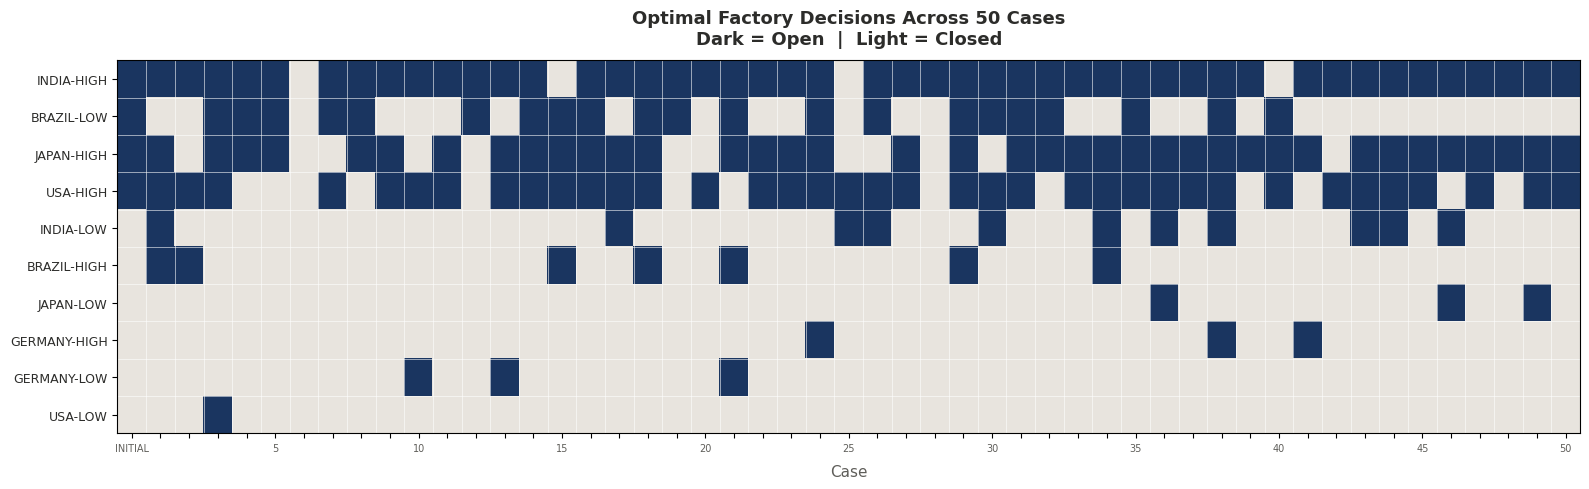

Saved: chart3_factory_heatmap.png


In [29]:
np.random.seed(42)   #  Factory heatmap across 50 cases
N = 50
 
factory_names = [
    'INDIA-HIGH', 'BRAZIL-LOW', 'JAPAN-HIGH', 'USA-HIGH',
    'INDIA-LOW',  'BRAZIL-HIGH','JAPAN-LOW',  'GERMANY-HIGH',
    'GERMANY-LOW','USA-LOW'
]
 
# base open/close from your model result
base_open = [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
 
# open probabilities per factory across simulated cases
probs = [0.92, 0.55, 0.75, 0.80, 0.18, 0.20, 0.05, 0.04, 0.03, 0.05]
 
# generate 50 cases
heatmap_data = np.zeros((len(factory_names), N+1))
heatmap_data[:, 0] = base_open   # initial solution (first column)
for c in range(N):
    for f in range(len(factory_names)):
        heatmap_data[f, c+1] = 1 if np.random.random() < probs[f] else 0
 
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
 
# draw cells
cell_colors = np.where(heatmap_data == 1, 1.0, 0.0)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'factory', ['#e8e4de', '#1a3560'])
ax.imshow(cell_colors, aspect='auto', cmap=cmap, vmin=0, vmax=1,
          interpolation='nearest')
 
ax.set_yticks(range(len(factory_names)))
ax.set_yticklabels(factory_names, fontsize=9, fontweight='500', color='#2C2C2A')
 
xtick_pos  = [0] + list(range(1, N+1, 5))
xtick_labs = ['INITIAL'] + [str(i) for i in range(1, N+1, 5)]
ax.set_xticks([p for p in range(0, N+1)])
ax.set_xticklabels(
    ['INITIAL'] + [str(i) if i % 5 == 0 else '' for i in range(1, N+1)],
    fontsize=7, color='#5F5E5A', rotation=0)
 
ax.set_xlabel('Case', fontsize=11, color='#5F5E5A', labelpad=8)
ax.set_title('Optimal Factory Decisions Across 50 Cases\n'
             'Dark = Open  |  Light = Closed',
             fontsize=13, fontweight='bold', color='#2C2C2A', pad=12)
ax.grid(False)
 
# add grid lines between cells
for x in range(-1, N+1):
    ax.axvline(x+0.5, color='white', linewidth=0.4)
for y in range(-1, len(factory_names)):
    ax.axhline(y+0.5, color='white', linewidth=0.4)
 
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'chart3_factory_heatmap.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart3_factory_heatmap.png")

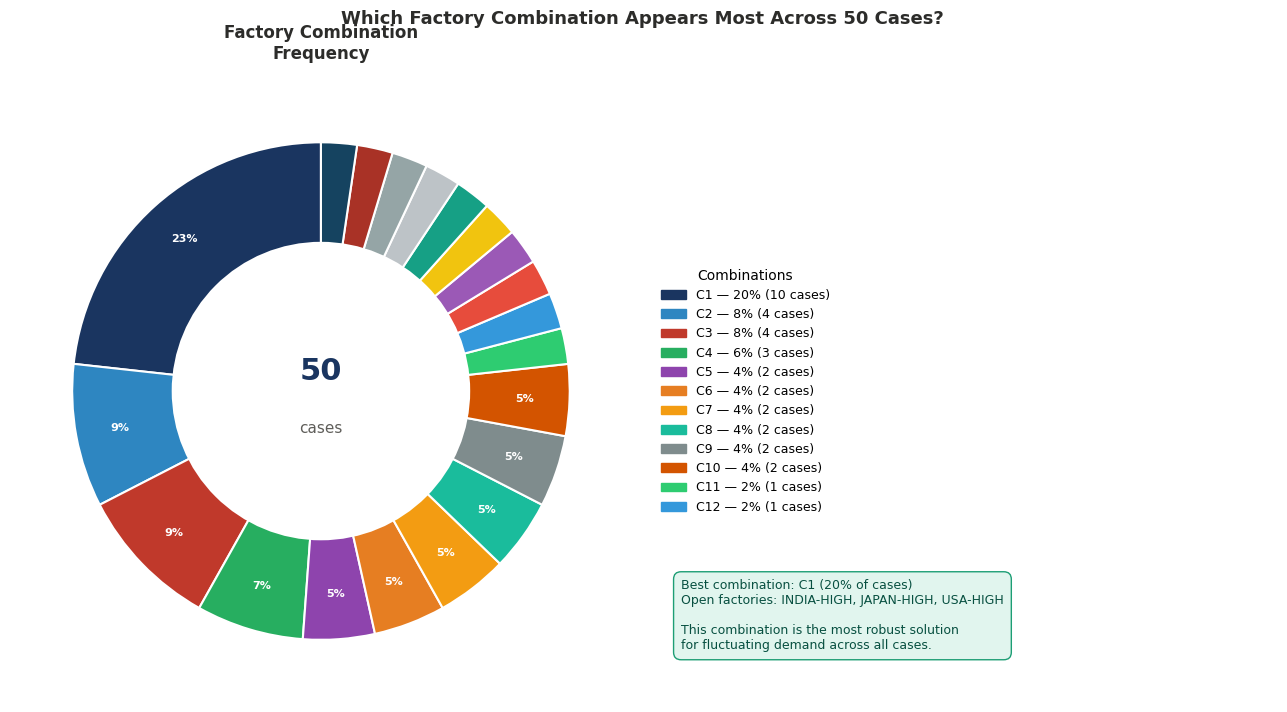

Saved: chart4_combination_donut.png


In [30]:
np.random.seed(42) # Combination frequency donut
N = 50
probs = [0.92, 0.55, 0.75, 0.80, 0.18, 0.20, 0.05, 0.04, 0.03, 0.05]
factory_names = [
    'INDIA-HIGH', 'BRAZIL-LOW', 'JAPAN-HIGH', 'USA-HIGH',
    'INDIA-LOW',  'BRAZIL-HIGH','JAPAN-LOW',  'GERMANY-HIGH',
    'GERMANY-LOW','USA-LOW'
]
 
combo_counts = {}
for _ in range(N):
    combo = tuple(1 if np.random.random() < p else 0 for p in probs)
    combo_counts[combo] = combo_counts.get(combo, 0) + 1
 
sorted_combos = sorted(combo_counts.items(), key=lambda x: -x[1])
 
colors_donut = [
    '#1a3560','#2E86C1','#C0392B','#27AE60','#8E44AD',
    '#E67E22','#F39C12','#1ABC9C','#7F8C8D','#D35400',
    '#2ECC71','#3498DB','#E74C3C','#9B59B6','#F1C40F',
    '#16A085','#BDC3C7','#95A5A6','#A93226','#154360'
]
 
labels_d, sizes_d, colors_d = [], [], []
for i, (combo, cnt) in enumerate(sorted_combos[:len(colors_donut)]):
    labels_d.append(f'C{i+1}')
    sizes_d.append(cnt)
    colors_d.append(colors_donut[i])
 
fig, (ax_donut, ax_leg) = plt.subplots(1, 2, figsize=(13, 7),
                                        gridspec_kw={'width_ratios':[1, 1]})
fig.patch.set_facecolor('white')
 
wedges, texts, autotexts = ax_donut.pie(
    sizes_d, labels=None, colors=colors_d,
    autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
    pctdistance=0.82, startangle=90,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    textprops={'fontsize': 8, 'color': 'white', 'fontweight': 'bold'})
 
centre_circle = plt.Circle((0,0), 0.60, fc='white')
ax_donut.add_artist(centre_circle)
ax_donut.text(0, 0.08, '50', ha='center', va='center',
              fontsize=22, fontweight='bold', color='#1a3560')
ax_donut.text(0, -0.15, 'cases', ha='center', va='center',
              fontsize=11, color='#5F5E5A')
ax_donut.set_title('Factory Combination\nFrequency', fontsize=12,
                   fontweight='bold', color='#2C2C2A', pad=15)
 
ax_leg.axis('off')
best_combo = sorted_combos[0][0]
best_count = sorted_combos[0][1]
best_pct   = round(best_count / N * 100)
best_facts = [factory_names[i] for i,v in enumerate(best_combo) if v==1]
 
legend_elements = []
for i, (lbl, cnt) in enumerate(zip(labels_d, sizes_d)):
    pct = round(cnt/N*100)
    marker = mpatches.Patch(color=colors_d[i], label=f'{lbl} — {pct}% ({cnt} cases)')
    legend_elements.append(marker)
 
ax_leg.legend(handles=legend_elements[:12], loc='center left',
              fontsize=9, frameon=False,
              title='Combinations', title_fontsize=10)
 
best_text = (f'Best combination: C1 ({best_pct}% of cases)\n'
             f'Open factories: {", ".join(best_facts)}\n\n'
             f'This combination is the most robust solution\n'
             f'for fluctuating demand across all cases.')
ax_leg.text(0.05, 0.08, best_text, transform=ax_leg.transAxes,
            fontsize=9, color='#085041',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#E1F5EE',
                      edgecolor='#1D9E75', linewidth=1),
            va='bottom')
 
fig.suptitle('Which Factory Combination Appears Most Across 50 Cases?',
             fontsize=13, fontweight='bold', color='#2C2C2A', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'chart4_combination_donut.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart4_combination_donut.png")
 